# 02 — Data pipeline audit

Read-only: everything below loads from `data/` as it already sits on disk. Nothing here re-runs `fetch_series.py` or `build_tidy_tables.py`, and nothing in `src/` is touched.

Every cell prints or displays actual numbers, not a pass/fail verdict — the test suite (`tests/test_data_coverage.py`) already does pass/fail. This notebook exists so you can look at the values yourself and judge them.

## 1. Setup
Imports, paths, and display options. Nothing to judge here — just wiring.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)


def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("no pyproject.toml found in any parent directory")


REPO_ROOT = find_repo_root(Path.cwd())
RAW_DIR = REPO_ROOT / "data" / "raw"
PROCESSED_DIR = REPO_ROOT / "data" / "processed"

## 2. What was fetched
File count and total size of `data/raw/`, plus the head of one raw file so you can see exactly what FRED returned before any parsing touched it.

**Would look wrong if:** the file count isn't 29 (one per manifest series), or the raw file's columns aren't `realtime_start, realtime_end, date, value` with `value` still a string (including `"."` for missing observations).

In [2]:
raw_files = sorted(RAW_DIR.glob("*.csv"))
total_size_mb = sum(f.stat().st_size for f in raw_files) / (1024 * 1024)
print(f"{len(raw_files)} files in data/raw/, {total_size_mb:.2f} MB total")

29 files in data/raw/, 1.96 MB total


In [3]:
sample_raw = pd.read_csv(RAW_DIR / "WCOILWTICO.csv")
sample_raw.head()

,realtime_start,realtime_end,date,value
0,2026-08-03,2026-08-03,2010-01-01,79.07
1,2026-08-03,2026-08-03,2010-01-08,82.34
2,2026-08-03,2026-08-03,2010-01-15,80.06
3,2026-08-03,2026-08-03,2010-01-22,76.62
4,2026-08-03,2026-08-03,2010-01-29,73.94


## 3. Fetch summary
One row per series: row count, date range, and how many observations were FRED's `"."` missing-value marker — joined to `kind`/`freq`/`role` from `data/processed/series_manifest.csv`, sorted by kind then freq.

**Would look wrong if:** fewer than 29 rows, a `nan_count` that looks high for a series you wouldn't expect gaps in, or a `first_date`/`last_date` that doesn't match what you expect for that series.

In [3]:
manifest_df = pd.read_csv(PROCESSED_DIR / "series_manifest.csv")

summary_rows = []
for path in sorted(RAW_DIR.glob("*.csv")):
    series_id = path.stem
    raw = pd.read_csv(path, dtype=str)
    summary_rows.append(
        {
            "series_id": series_id,
            "rows": len(raw),
            "first_date": raw["date"].min(),
            "last_date": raw["date"].max(),
            "nan_count": (raw["value"] == ".").sum(),
        }
    )

fetch_summary = pd.DataFrame(summary_rows).merge(
    manifest_df[["series_id", "kind", "freq", "role"]], on="series_id", how="left"
)
fetch_summary = fetch_summary.sort_values(["kind", "freq"]).reset_index(drop=True)
fetch_summary

,series_id,rows,first_date,last_date,nan_count,kind,freq,role
0,DCOILBRENTEU,4322,2010-01-01,2026-07-27,131,crude,daily,robustness
1,DCOILWTICO,4322,2010-01-01,2026-07-27,168,crude,daily,core
2,WCOILBRENTEU,865,2010-01-01,2026-07-24,0,crude,weekly-fri,robustness
3,WCOILWTICO,865,2010-01-01,2026-07-24,0,crude,weekly-fri,core
4,GASDESECW,865,2010-01-04,2026-07-27,0,retail,weekly-mon,placebo
5,GASDESGCW,865,2010-01-04,2026-07-27,0,retail,weekly-mon,placebo
6,GASDESMWW,865,2010-01-04,2026-07-27,0,retail,weekly-mon,placebo
7,GASDESRMW,865,2010-01-04,2026-07-27,0,retail,weekly-mon,placebo
8,GASDESW,865,2010-01-04,2026-07-27,0,retail,weekly-mon,placebo
9,GASDESWCW,865,2010-01-04,2026-07-27,0,retail,weekly-mon,placebo


## 4. Tidy tables
Shape, `freq` value counts, and the first 3 rows of each of `crude.csv`, `spot.csv`, `retail.csv`.

**Would look wrong if:** a table's row count doesn't roughly match section 3's totals for that `kind`.

In [4]:
crude = pd.read_csv(PROCESSED_DIR / "crude.csv", parse_dates=["date"])
spot = pd.read_csv(PROCESSED_DIR / "spot.csv", parse_dates=["date"])
retail = pd.read_csv(PROCESSED_DIR / "retail.csv", parse_dates=["date"])

tables = {"crude": crude, "spot": spot, "retail": retail}

for name, df in tables.items():
    print(f"--- {name}: shape ---")
    print(df.shape)
    print(df["freq"].value_counts())
    print()

--- crude: shape ---
(10374, 6)
freq
daily         8644
weekly-fri    1730
Name: count, dtype: int64

--- spot: shape ---
(31126, 7)
freq
daily         25936
weekly-fri     5190
Name: count, dtype: int64

--- retail: shape ---
(11245, 7)
freq
weekly-mon    11245
Name: count, dtype: int64



In [5]:
for name, df in tables.items():
    print(f"--- {name}: head(3) ---")
    display(df.head(3))

--- crude: head(3) ---


,date,series_id,benchmark,freq,price_usd_per_barrel,price_usd_per_gallon
0,2010-01-01,DCOILBRENTEU,Brent,daily,NaN,NaN
1,2010-01-04,DCOILBRENTEU,Brent,daily,79.05,1.882143
2,2010-01-05,DCOILBRENTEU,Brent,daily,79.27,1.887381


--- spot: head(3) ---


,date,series_id,hub,fuel,formulation,freq,price_usd_per_gallon
0,2010-01-01,DDFUELLA,Los Angeles,diesel,NaN,daily,NaN
1,2010-01-04,DDFUELLA,Los Angeles,diesel,NaN,daily,2.209
2,2010-01-05,DDFUELLA,Los Angeles,diesel,NaN,daily,2.190


--- retail: head(3) ---


,date,series_id,region,fuel,formulation,freq,price_usd_per_gallon
0,2010-01-04,GASDESECW,PADD 1,diesel,NaN,weekly-mon,2.827
1,2010-01-11,GASDESECW,PADD 1,diesel,NaN,weekly-mon,2.922
2,2010-01-18,GASDESECW,PADD 1,diesel,NaN,weekly-mon,2.923


## 5. Coverage
Four checks, each showing the actual rows rather than a pass/fail:
- day-of-week counts per `freq`, for each table
- every retail observation where the gap to the previous one (same series) isn't 7 days
- every row with a negative price, in any table
- every weekend row in a daily series, and whether its price is null

**Would look wrong if:** a `weekly-fri` series has any day other than Friday, a `weekly-mon` series has any day other than Monday, a daily series has any Saturday/Sunday count at all, the retail-gap table has more than a small handful of rows, a negative price shows up on a date/series you don't recognize as a known real event, or a weekend daily row shows `price_is_null = False`.

In [6]:
for name, df in tables.items():
    print(f"=== {name}: day-of-week counts by freq ===")
    for freq, group in df.groupby("freq"):
        print(f"-- {freq} --")
        print(group["date"].dt.day_name().value_counts())
    print()

=== crude: day-of-week counts by freq ===
-- daily --
date
Friday       1730
Monday       1730
Tuesday      1728
Wednesday    1728
Thursday     1728
Name: count, dtype: int64
-- weekly-fri --
date
Friday    1730
Name: count, dtype: int64

=== spot: day-of-week counts by freq ===
-- daily --
date
Friday       5190
Monday       5190
Tuesday      5184
Wednesday    5184
Thursday     5184
Saturday        4
Name: count, dtype: int64
-- weekly-fri --
date
Friday    5190
Name: count, dtype: int64

=== retail: day-of-week counts by freq ===
-- weekly-mon --
date
Monday    11245
Name: count, dtype: int64



In [7]:
retail_sorted = retail.sort_values(["series_id", "date"]).copy()
retail_sorted["gap_days"] = retail_sorted.groupby("series_id")["date"].diff().dt.days

irregular_gaps = retail_sorted[retail_sorted["gap_days"].notna() & (retail_sorted["gap_days"] != 7)]
irregular_gaps[["series_id", "date", "gap_days"]]

,series_id,date,gap_days


In [8]:
negative_crude = crude[(crude["price_usd_per_barrel"] < 0) | (crude["price_usd_per_gallon"] < 0)]
negative_spot = spot[spot["price_usd_per_gallon"] < 0]
negative_retail = retail[retail["price_usd_per_gallon"] < 0]

print("negative crude rows:")
display(negative_crude)
print("negative spot rows:")
display(negative_spot)
print("negative retail rows:")
display(negative_retail)

negative crude rows:


,date,series_id,benchmark,freq,price_usd_per_barrel,price_usd_per_gallon
7008,2020-04-20,DCOILWTICO,WTI,daily,-36.98,-0.880476


negative spot rows:


,date,series_id,hub,fuel,formulation,freq,price_usd_per_gallon


negative retail rows:


,date,series_id,region,fuel,formulation,freq,price_usd_per_gallon


In [9]:
price_col_by_table = {"crude": "price_usd_per_barrel", "spot": "price_usd_per_gallon", "retail": "price_usd_per_gallon"}

weekend_daily_frames = []
for name, df in tables.items():
    daily = df[df["freq"] == "daily"].copy()
    if daily.empty:
        continue
    weekend = daily[daily["date"].dt.dayofweek >= 5].copy()
    weekend["table"] = name
    weekend["price_is_null"] = weekend[price_col_by_table[name]].isna()
    weekend_daily_frames.append(weekend[["table", "series_id", "date", "price_is_null"]])

weekend_daily = (
    pd.concat(weekend_daily_frames, ignore_index=True)
    if weekend_daily_frames
    else pd.DataFrame(columns=["table", "series_id", "date", "price_is_null"])
)
weekend_daily

,table,series_id,date,price_is_null
0,spot,DDFUELNYH,2010-11-13,True
1,spot,DDFUELNYH,2010-11-20,True
2,spot,DDFUELUSGULF,2010-11-13,True
3,spot,DDFUELUSGULF,2010-11-20,True


## 6. The plot
WTI crude ($/barrel) on top, US retail regular gasoline ($/gal) below, sharing an x-axis, 2010\u2192now, gridlines on.

**Would look wrong if:** the two series don't broadly move together, retail looks implausibly smoother or choppier than crude, or either panel has a visible gap that isn't explained by section 3's `nan_count`.

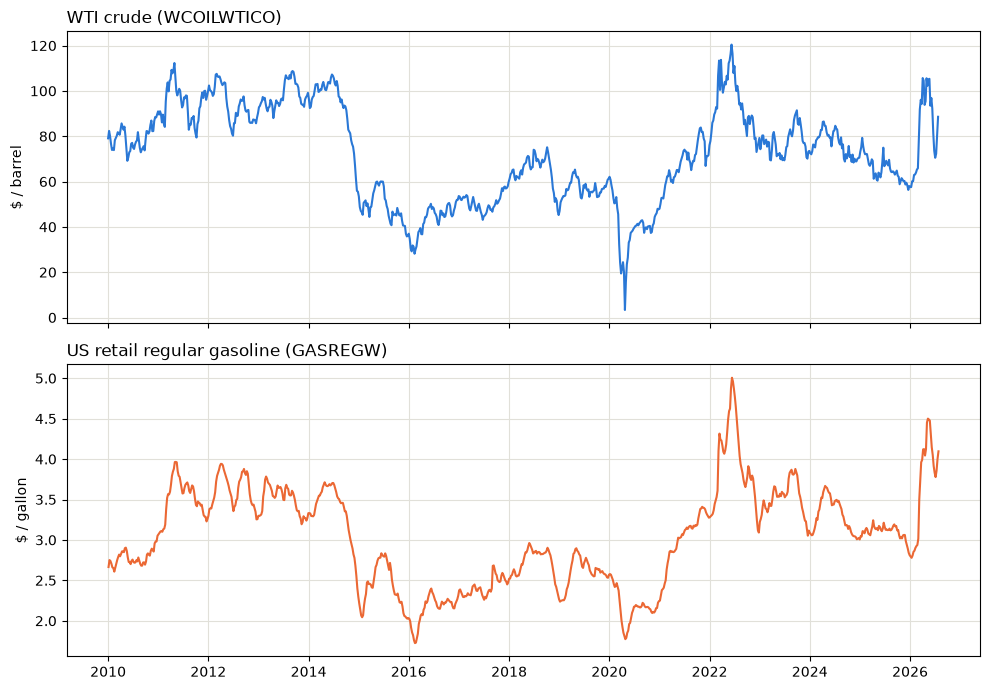

In [10]:
wti = crude[(crude["series_id"] == "WCOILWTICO") & (crude["date"] >= "2010-01-01")]
retail_us = retail[(retail["series_id"] == "GASREGW") & (retail["date"] >= "2010-01-01")]

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax_top.plot(wti["date"], wti["price_usd_per_barrel"], color="#2a78d6", linewidth=1.5)
ax_top.set_ylabel("$ / barrel")
ax_top.set_title("WTI crude (WCOILWTICO)", loc="left")
ax_top.grid(True, color="#e1e0d9")

ax_bottom.plot(retail_us["date"], retail_us["price_usd_per_gallon"], color="#eb6834", linewidth=1.5)
ax_bottom.set_ylabel("$ / gallon")
ax_bottom.set_title("US retail regular gasoline (GASREGW)", loc="left")
ax_bottom.grid(True, color="#e1e0d9")

plt.tight_layout()
plt.show()

## 7. Observations

- **`DCOILWTICO` went negative on 2020-04-20 (-$36.98)** — the one row in section 5's negative-price check, across all three tables. Real: the day WTI futures went negative for the first time in history (COVID demand collapse collided with storage running out). Not flagging it as wrong.
- **4 weekend rows, all `NaN`**, in `DDFUELNYH`/`DDFUELUSGULF` only, both on Saturdays 2010-11-13 and 2010-11-20, when no data on prices should be given.
- **Everything else came back completely clean** — zero irregular retail gaps across 13 series (~865 weeks each), zero negative spot/retail prices, every `weekly-fri`/`weekly-mon` row lands on exactly the right weekday with no exceptions.
